# Finding Planets in Your Own Simulation

**Companion lesson:** [`keplerian_rv_lesson.md`](keplerian_rv_lesson.md). Read it first; this notebook assumes the physics and statistics from there.

In `mcmc_exoplanet.py` you fitted **one** parameter (the amplitude) of a sine wave whose period and phase you already knew. Real planet hunters know none of that. In this notebook you will:

1. **Simulate** a star + planet with *your own* leapfrog integrator and record the star's wobble as noisy "telescope" data.
2. **Build** the Keplerian radial-velocity model: Kepler's equation, true anomaly, the RV equation.
3. **Verify** the analytic model against the N-body simulation. Two completely independent methods should agree.
4. **Write** a 7-parameter posterior with priors and a jitter term.
5. **Implement** the Goodman & Weare affine-invariant ensemble sampler (the algorithm inside `emcee`) from scratch.
6. **Diagnose** convergence with the integrated autocorrelation time.
7. **Recover** the planet's minimum mass $m \sin i$, and compare it to the truth you injected.

### How to work through it
- Cells marked **✏️ TODO** contain `raise NotImplementedError`. Replace it with your code.
- Every TODO is followed by a **✅ Check** cell. Run it; it tells you whether your implementation is right before you build on it.
- Everything else is provided. Read it, but you don't need to change it.
- Run cells top to bottom. If something goes weird, *Kernel → Restart & Run All*.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

# Make the repo root importable so we can reuse the gravity engine you built.
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "gravity").is_dir())
sys.path.insert(0, str(REPO_ROOT))
from gravity.earth_sun_moon_simulation import G, Body, compute_accelerations, leapfrog_step, total_energy

plt.style.use("dark_background")
plt.rcParams.update({"figure.facecolor": "#050b18", "axes.facecolor": "#050b18", "figure.figsize": (10, 4)})

M_SUN = 1.98847e30   # kg
M_JUP = 1.89813e27   # kg
DAY = 86_400.0       # s

rng = np.random.default_rng(2029)

---
## Part 1: A star, a planet, and your leapfrog integrator

These are the **true** parameters of our hidden planet. In Part 4 we'll pretend we never saw them.

The planet starts at **periastron** (closest approach) at $t = 0$, with its periastron pointing at angle `PHI` in the orbital plane. We observe the system **edge-on** ($i = 90°$) along the $y$-axis. The star's $v_y$ *is* its radial velocity (positive = moving away from us).

In [2]:
M_STAR = 1.0 * M_SUN
M_PLANET = 2.0 * M_JUP
P_TRUE = 111.4           # orbital period, days
E_TRUE = 0.35            # eccentricity
PHI = 1.1                # direction of the planet's periastron in the x-y plane, radians
GAMMA_TRUE = -12.0       # systemic velocity of the whole system, m/s
JITTER_TRUE = 3.0        # extra stellar "noise" not captured by error bars, m/s

### ✏️ TODO 1: Initial conditions for an eccentric orbit

Place the two bodies at periastron so that:

- the **relative** orbit has period `P` and eccentricity `e`,
- the **centre of mass** sits at the origin and is **at rest** (zero total momentum).

Recipe (see the lesson, *"Setting up the two-body problem"*):

1. Semi-major axis of the relative orbit from Kepler's third law: $a = \left(\dfrac{G(M+m)P^2}{4\pi^2}\right)^{1/3}$
2. Periastron distance $r_p = a(1-e)$ and vis-viva speed $v_p = \sqrt{\dfrac{G(M+m)}{a}\,\dfrac{1+e}{1-e}}$
3. The relative position points along $\hat{u} = (\cos\phi, \sin\phi)$. The relative velocity is perpendicular and counter-clockwise: $\hat{w} = (-\sin\phi, \cos\phi)$
4. Split between the bodies: the planet gets $+\dfrac{M}{M+m}$ of the relative vector and the star gets $-\dfrac{m}{M+m}$ of it.

Remember the simulation works in **SI units** (metres, seconds, kg), but `P` is given in days.

In [3]:
def two_body_initial_conditions(m_star, m_planet, period_days, e, phi):
    '''Return [star, planet] as Body objects at periastron, centre of mass at rest at the origin.'''
    # ✏️ YOUR CODE HERE
    period_seconds = period_days * DAY
    a = (G * (m_star + m_planet) * period_seconds**2 /(4*np.pi**2) )**(1/3)
    periastron = a*(1-e)
    vis_viva_speed = ((G * (m_star + m_planet) * (1+e)) / (a * (1-e)))**0.5
    initial_pos = np.array([periastron*np.cos(phi), periastron*np.sin(phi)])
    rel_velocity_unscaled = np.array([-vis_viva_speed*np.sin(phi), vis_viva_speed*np.cos(phi)]) # Parallel to derivative of r = (cos(x), sin(x))

    # Class Body; name: str; mass: float; x: float; y: float; vx: float; vy: float; color: str
    star = Body(
        "star",
        m_star, 
        -m_planet*initial_pos[0]/(m_star + m_planet), 
        -m_planet*initial_pos[1]/(m_star + m_planet), 
        -m_planet*rel_velocity_unscaled[0]/(m_star + m_planet), 
        -m_planet*rel_velocity_unscaled[1]/(m_star + m_planet), 
        "#f6c431")  
    
    planet = Body(
        "planet",
        m_planet, 
        m_star*initial_pos[0]/(m_star + m_planet), 
        m_star*initial_pos[1]/(m_star + m_planet), 
        m_star*rel_velocity_unscaled[0]/(m_star + m_planet), 
        m_star*rel_velocity_unscaled[1]/(m_star + m_planet), 
        "#9ca3af")
    
    return [star, planet]

### ✅ Check 1

In [4]:
_bodies = two_body_initial_conditions(M_STAR, M_PLANET, P_TRUE, E_TRUE, PHI)
_px = sum(b.mass * b.vx for b in _bodies); _py = sum(b.mass * b.vy for b in _bodies)
_cx = sum(b.mass * b.x for b in _bodies);  _cy = sum(b.mass * b.y for b in _bodies)
assert abs(_px) + abs(_py) < 1e-6 * _bodies[1].mass * 3e4, "Total momentum should be zero"
assert abs(_cx) + abs(_cy) < 1e-6 * _bodies[1].mass * 1e11, "Centre of mass should be at the origin"
# Specific orbital energy of the relative orbit must equal -G(M+m)/(2a)
_mt = M_STAR + M_PLANET
_a = (G * _mt * (P_TRUE * DAY) ** 2 / (4 * np.pi**2)) ** (1 / 3)
_dvx, _dvy = _bodies[1].vx - _bodies[0].vx, _bodies[1].vy - _bodies[0].vy
_r = np.hypot(_bodies[1].x - _bodies[0].x, _bodies[1].y - _bodies[0].y)
assert np.isclose(0.5 * (_dvx**2 + _dvy**2) - G * _mt / _r, -G * _mt / (2 * _a), rtol=1e-9), "Vis-viva speed looks wrong"
assert np.isclose(_r, _a * (1 - E_TRUE), rtol=1e-9), "Separation should be the periastron distance a(1-e)"
print(f"✅ Initial conditions look right. a = {_a / 1.496e11:.3f} AU")

✅ Initial conditions look right. a = 0.453 AU


### Run the simulation and "observe" it

This part is provided. It steps your `leapfrog_step` forward, records the star's $v_y$, and then builds a realistic data set:

- **60 observations** over ~3 years, but only when the star is up at night (it's behind the Sun ~4 months a year). These **seasonal gaps** matter later.
- Each point has its own error bar $\sigma_i$ (2–5 m/s), plus a hidden **stellar jitter** of 3 m/s that the error bars *don't* account for.

Simulated 22,001 steps. Relative energy drift: 5.5e-06


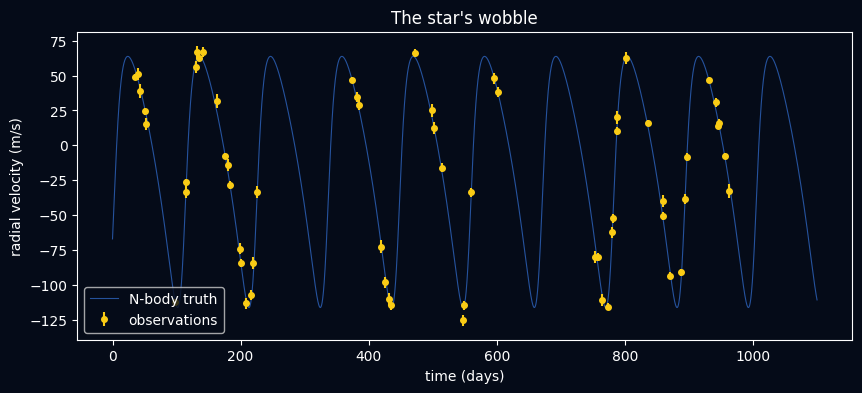

In [5]:
def simulate_star_rv(bodies, days, dt_days):
    '''Integrate with leapfrog, returning (times in days, star v_y in m/s, relative energy drift).'''
    dt = dt_days * DAY
    steps = int(round(days / dt_days))
    times = np.arange(steps + 1) * dt_days
    star_vy = np.empty(steps + 1)
    star_vy[0] = bodies[0].vy
    e0 = total_energy(bodies)
    acc = compute_accelerations(bodies)
    for n in range(1, steps + 1):
        acc = leapfrog_step(bodies, dt, acc)
        star_vy[n] = bodies[0].vy
    return times, star_vy, abs(total_energy(bodies) / e0 - 1)


BASELINE_DAYS = 1100.0
sim_t, sim_vy, drift = simulate_star_rv(
    two_body_initial_conditions(M_STAR, M_PLANET, P_TRUE, E_TRUE, PHI), BASELINE_DAYS, dt_days=0.05
)
print(f"Simulated {len(sim_t):,} steps. Relative energy drift: {drift:.1e}")

# Observing schedule: the star is only visible for 240 days of each year.
N_OBS = 60
candidates = rng.uniform(0, BASELINE_DAYS, 20 * N_OBS)
t_obs = np.sort(rng.choice(candidates[(candidates % 365.25) < 240], N_OBS, replace=False))
rv_err = rng.uniform(2.0, 5.0, N_OBS)
rv_clean = np.interp(t_obs, sim_t, sim_vy) + GAMMA_TRUE
rv_obs = rv_clean + rng.normal(0, np.sqrt(rv_err**2 + JITTER_TRUE**2))

fig, ax = plt.subplots()
ax.plot(sim_t, sim_vy + GAMMA_TRUE, color="#3b82f6", lw=0.8, alpha=0.6, label="N-body truth")
ax.errorbar(t_obs, rv_obs, rv_err, fmt="o", ms=4, color="#facc15", label="observations")
ax.set(xlabel="time (days)", ylabel="radial velocity (m/s)", title="The star's wobble")
ax.legend();

Notice the curve is **not a sine wave**. The star whips quickly through periastron and lingers near apoastron. That asymmetry is how we measure eccentricity.

---
## Part 2: The Keplerian RV model

The N-body simulation is a numerical solution. For a single planet there is also an **exact analytic** solution, and that's what we'll fit. It takes three steps from time to velocity:

$$t \;\xrightarrow{\text{mean anomaly}}\; M \;\xrightarrow{\text{Kepler's equation}}\; E \;\xrightarrow{\text{geometry}}\; \nu \;\xrightarrow{\text{RV equation}}\; v_r$$

### ✏️ TODO 2: Solve Kepler's equation

Find the eccentric anomaly $E$ satisfying $E - e\sin E = M$. There's no closed form, so use **Newton-Raphson**:

$$E_{n+1} = E_n - \frac{E_n - e\sin E_n - M}{1 - e\cos E_n}$$

Requirements:
- `M` may be a NumPy **array**. Solve every element at once (no Python loop over elements).
- Start from $E_0 = M + e\sin M$ (a good guess even at high $e$).
- Iterate until the largest correction is below `tol`, or `max_iter` is reached.

In [6]:
def solve_kepler(M, e, tol=1e-12, max_iter=50):
    '''Eccentric anomaly E (radians) with E - e sin E = M, vectorized over M.'''
    M = np.asarray(M, dtype=float)
    # ✏️ YOUR CODE HERE

    E0 = M + e * np.sin(M)
    En = E0

    for i in range(max_iter):
        num = En - e * np.sin(En) - M
        denom = 1 - e * np.cos(En)

        En = En - num / denom

        if np.all(np.abs(np.max(num/denom)) < tol):
            break
    return En


### ✅ Check 2

In [7]:
_M = np.linspace(0, 2 * np.pi, 1000)
for _e in [0.0, 0.3, 0.7, 0.95]:
    _E = solve_kepler(_M, _e)
    assert _E.shape == _M.shape, "Return an array the same shape as M"
    assert np.max(np.abs(_E - _e * np.sin(_E) - _M)) < 1e-10, f"Kepler's equation not satisfied at e={_e}"
assert np.allclose(solve_kepler(_M, 0.0), _M), "With e=0, E should equal M"
print("✅ Kepler solver works, even at e = 0.95")

✅ Kepler solver works, even at e = 0.95


### ✏️ TODO 3: The radial-velocity model

Put the pieces together. For parameters $(P, K, e, \omega, M_0, \gamma)$:

1. **Mean anomaly** (grows uniformly in time): $M = \dfrac{2\pi}{P}(t - t_\text{ref}) + M_0$, where $M_0$ is the mean anomaly at the reference time `T_REF`.
2. **Eccentric anomaly:** `solve_kepler(M, e)`
3. **True anomaly** (the actual angle from periastron): $\nu = 2\,\operatorname{atan2}\!\left(\sqrt{1+e}\,\sin\tfrac{E}{2},\;\sqrt{1-e}\,\cos\tfrac{E}{2}\right)$
4. **Radial velocity:** $v_r = K\left[\cos(\nu + \omega) + e\cos\omega\right] + \gamma$

Here $\omega$ is the argument of periastron **of the star's orbit**.

In [18]:
T_REF = 500.0  # reference epoch (days) for the phase parameter M0


def keplerian_rv(t, P, K, e, omega, M0, gamma):
    '''Radial velocity (m/s) of a star orbited by one planet, at times t (days).'''
    # ✏️ YOUR CODE HERE
    M = 2*np.pi/P * (t - T_REF) + M0
    E = solve_kepler(M,e)
    nu = 2 * np.atan2(np.sin(E/2) * (1+e)**0.5, np.cos(E/2) * (1-e)**0.5)
    vr = K * (np.cos(nu + omega) + e*np.cos(omega)) + gamma

    return vr

### ✏️ TODO 4: The true parameters, in model language

To compare the model with the simulation, translate our physical set-up into the model's parameters:

- **$K$**, the semi-amplitude: $K = \left(\dfrac{2\pi G}{P}\right)^{1/3} \dfrac{m\sin i}{(M+m)^{2/3}} \dfrac{1}{\sqrt{1-e^2}}$ (SI units in, m/s out; here $\sin i = 1$).
- **$\omega$**: the star sits on the *opposite* side of the centre of mass from the planet. Where does the *star's* periastron point, given the planet's points at `PHI`? Wrap it into $[0, 2\pi)$.
- **$M_0$**: the planet was at periastron ($M = 0$) at $t = 0$. What is $M$ at $t = $ `T_REF`? Wrap it into $[0, 2\pi)$.

In [19]:
def semi_amplitude(m_star, m_planet_sini, period_days, e):
    '''RV semi-amplitude K in m/s. Masses in kg, period in days.'''
    # ✏️ YOUR CODE HERE`
    
    P = period_days * DAY
    K = (2*np.pi*G/P)**(1/3) * m_planet_sini / (m_star + m_planet_sini)**(2/3) * 1/np.sqrt(1-e**2)
    return K


K_TRUE = semi_amplitude(M_STAR, M_PLANET, P_TRUE, E_TRUE)
OMEGA_TRUE = (PHI + np.pi) % (2*np.pi)  # ✏️ TODO: where does the STAR's periastron point? Wrap into [0, 2π)
M0_TRUE = ((T_REF) * 2*np.pi/P_TRUE ) % (2*np.pi) # ✏️ TODO: the planet's mean anomaly at t = T_REF. Wrap into [0, 2π)
assert OMEGA_TRUE is not ... and M0_TRUE is not ..., "Fill in OMEGA_TRUE and M0_TRUE above"
print(f"K = {K_TRUE:.2f} m/s,  omega = {OMEGA_TRUE:.3f} rad,  M0 = {M0_TRUE:.3f} rad")

K = 90.07 m/s,  omega = 4.242 rad,  M0 = 3.068 rad


### ✅ Check 3 & 4: Does your analytic model match your N-body simulation?

This is the moment of truth. Two **completely independent** calculations are compared: one numerically integrates Newton's law step by step, the other solves Kepler's equation. If your initial conditions, Kepler solver, RV equation and parameter translation are all right, they agree to within the leapfrog's tiny integration error.

Look closely at the red difference curve: it **grows** with time. Leapfrog conserves energy, but its orbital *period* is very slightly wrong (by an amount $\propto \Delta t^2$), so the simulated planet slowly drifts ahead of or behind the exact solution. **Try it:** rerun the simulation cell with `dt_days=0.025`. The difference should shrink by a factor of 4. That's the $\Delta t^2$ scaling in action.

✅ Max |Keplerian - N-body| = 0.119 m/s (on a 90 m/s signal) over 1100 days. Two methods, one answer.


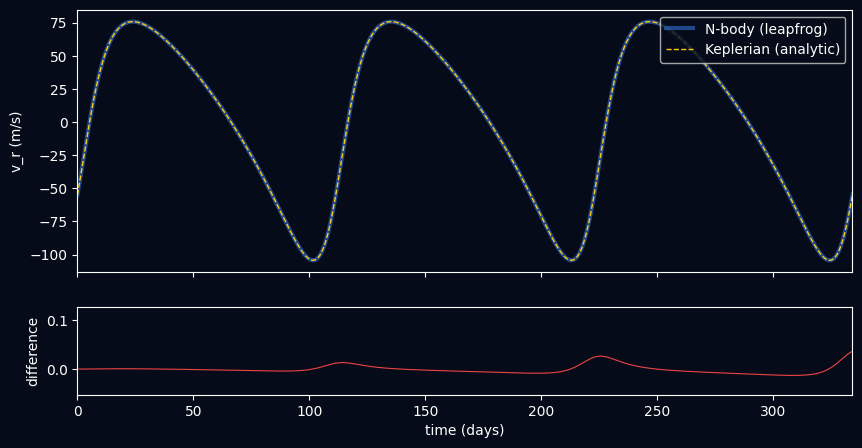

In [20]:
_model = keplerian_rv(sim_t, P_TRUE, K_TRUE, E_TRUE, OMEGA_TRUE, M0_TRUE, 0.0)
_max_diff = np.max(np.abs(_model - sim_vy))

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 5), height_ratios=[3, 1])
ax1.plot(sim_t, sim_vy, color="#3b82f6", lw=3, alpha=0.5, label="N-body (leapfrog)")
ax1.plot(sim_t, _model, color="#facc15", lw=1, ls="--", label="Keplerian (analytic)")
ax1.set_ylabel("v_r (m/s)"); ax1.legend(loc="upper right")
ax2.plot(sim_t, _model - sim_vy, color="#ef4444", lw=0.8)
ax2.set(xlabel="time (days)", ylabel="difference"); ax1.set_xlim(0, 3 * P_TRUE)

assert np.isclose(np.ptp(sim_vy) / 2, K_TRUE, rtol=1e-3), "K doesn't match the simulated peak-to-peak / 2"
assert _max_diff < 0.5, f"Model and simulation differ by up to {_max_diff:.2f} m/s; check omega, M0 and the RV equation"
print(f"✅ Max |Keplerian - N-body| = {_max_diff:.3f} m/s (on a {K_TRUE:.0f} m/s signal) over {BASELINE_DAYS:.0f} days. Two methods, one answer.")

---
## Part 3: The posterior

From here on, **forget the true values**. All we have is `t_obs`, `rv_obs` and `rv_err`.

We sample in a re-parametrized vector with **7 parameters** (the lesson explains why each choice matters):

| index | parameter | meaning | prior |
|---|---|---|---|
| 0 | $\ln P$ | log period (days) | uniform on $[\ln 1, \ln 1000]$ |
| 1 | $\ln K$ | log semi-amplitude (m/s) | uniform on $[\ln 0.1, \ln 1000]$ |
| 2 | $h = \sqrt{e}\cos\omega$ | | $h^2 + k^2 < 1$ |
| 3 | $k = \sqrt{e}\sin\omega$ | | (together: uniform in $e$ and $\omega$) |
| 4 | $M_0$ | mean anomaly at `T_REF` | uniform on $[0, 2\pi)$ |
| 5 | $\gamma$ | systemic velocity (m/s) | uniform on $[-1000, 1000]$ |
| 6 | $\ln s$ | log jitter (m/s) | uniform on $[\ln 0.01, \ln 100]$ |

### ✏️ TODO 5: Priors, likelihood, posterior

- `unpack(theta)` converts the sampling vector into physical parameters (provided).
- `log_prior(theta)` returns `0.0` if every parameter is inside its bounds, otherwise `-np.inf`. (Uniform priors are constant inside the box, and the constant doesn't matter.)
- `log_likelihood(theta, t, rv, err)` is a Gaussian likelihood whose variance **includes the jitter**: $\sigma_i^2 \to \sigma_i^2 + s^2$. Because $s$ is now a free parameter, you **must** keep the normalization term:

$$\ln \mathcal{L} = -\frac{1}{2}\sum_i \left[\frac{(v_i - m_i)^2}{\sigma_i^2 + s^2} + \ln\!\big(2\pi(\sigma_i^2 + s^2)\big)\right]$$

- `log_probability` adds them, but must **not** call the likelihood when the prior is $-\infty$ (e.g. $e \ge 1$ would crash the Kepler solver).

In [ ]:
LABELS = ["ln P", "ln K", "h", "k", "M0", "gamma", "ln s"]


def unpack(theta):
    '''Sampling vector -> physical (P, K, e, omega, M0, gamma, s).'''
    ln_P, ln_K, h, k, M0, gamma, ln_s = theta
    e = h**2 + k**2
    omega = np.arctan2(k, h)
    return np.exp(ln_P), np.exp(ln_K), e, omega, M0, gamma, np.exp(ln_s)


def log_prior(theta):
    # ✏️ YOUR CODE HERE
    ln_P, ln_K, h, k, M0, gamma, ln_s = theta

    return any([
        -np.inf if ln_P < np.log(1) or ln_P > np.log(1000) else 0,
        -np.inf if ln_K < np.log(0.1) or ln_K > np.log(1000) else 0,
        -np.inf if h**2 + k**2 >= 1 else 0,
        -np.inf if M0 < 0 or M0 > 2*np.pi else 0,
        -np.inf if ln_s < np.log(1e-3) or ln_s > np.log(100) else 0
    ])


def log_likelihood(theta, t, rv, err):
    # ✏️ YOUR CODE HERE
    -0.5 * np.sum()
    raise NotImplementedError("Replace this line with your implementation")


def log_probability(theta, t=t_obs, rv=rv_obs, err=rv_err):
    # ✏️ YOUR CODE HERE
    raise NotImplementedError("Replace this line with your implementation")

### ✅ Check 5

In [ ]:
_theta_true = np.array([np.log(P_TRUE), np.log(K_TRUE), np.sqrt(E_TRUE) * np.cos(OMEGA_TRUE),
                        np.sqrt(E_TRUE) * np.sin(OMEGA_TRUE), M0_TRUE, GAMMA_TRUE, np.log(JITTER_TRUE)])
assert np.allclose(unpack(_theta_true)[:4], [P_TRUE, K_TRUE, E_TRUE, OMEGA_TRUE - 2 * np.pi]) or \
       np.allclose(unpack(_theta_true)[:4], [P_TRUE, K_TRUE, E_TRUE, OMEGA_TRUE])
assert log_prior(_theta_true) == 0.0, "The true parameters should be inside the prior"
for _i, _bad in [(2, 1.5), (4, 7.0), (4, -0.1), (6, 10.0), (0, 10.0)]:
    _t = _theta_true.copy(); _t[_i] = _bad
    assert log_prior(_t) == -np.inf, f"{LABELS[_i]} = {_bad} should be outside the prior"
    assert log_probability(_t) == -np.inf, "log_probability must return -inf outside the prior"
# A tiny three-point likelihood you can check by hand
_ll = log_likelihood(np.array([np.log(10.0), np.log(1.0), 0, 0, 0, 5.0, np.log(1.0)]),
                     np.array([T_REF]), np.array([7.0]), np.array([1.0]))
assert np.isclose(_ll, -0.5 * (1.0 / 2.0 + np.log(2 * np.pi * 2.0))), "Likelihood must use err^2 + s^2 and include the log term"
print(f"✅ Posterior works. ln p(true params) = {log_probability(_theta_true):.1f}")

---
## Part 4: Where do we even start? (periodogram + optimizer)

A 7-D posterior with a period that could be anything from 1 to 1000 days is a terrible place to drop a random walker. The standard workflow is:

1. **Periodogram:** for each trial period, fit the best sinusoid by linear least squares and record how much it reduces $\chi^2$. Peaks = candidate periods.
2. **Optimize** from the best peak to find the maximum a posteriori (MAP) point.
3. **Sample** in a small ball around the MAP.

This is all provided. Look at the periodogram carefully: you should see **alias** peaks caused by the yearly observing gaps (the lesson explains where they come from).

In [ ]:
def periodogram(t, rv, err, periods):
    '''Fractional chi^2 reduction of the best-fit sinusoid (+ offset) at each trial period.'''
    w = 1 / err**2
    chi2_flat = np.sum(w * (rv - np.average(rv, weights=w)) ** 2)
    power = np.empty(len(periods))
    for n, P in enumerate(periods):
        A = np.column_stack([np.ones_like(t), np.sin(2 * np.pi * t / P), np.cos(2 * np.pi * t / P)])
        coeffs, *_ = np.linalg.lstsq(A * np.sqrt(w)[:, None], rv * np.sqrt(w), rcond=None)
        power[n] = 1 - np.sum(w * (rv - A @ coeffs) ** 2) / chi2_flat
    return power


trial_periods = np.exp(np.linspace(np.log(2), np.log(1000), 40_000))
power = periodogram(t_obs, rv_obs, rv_err, trial_periods)
P_best = trial_periods[np.argmax(power)]

fig, ax = plt.subplots()
ax.semilogx(trial_periods, power, color="#8b5cf6", lw=0.8)
ax.axvline(P_best, color="#facc15", ls="--", label=f"best peak: {P_best:.2f} d")
for alias in [1 / (1 / P_best + 1 / 365.25), 1 / (1 / P_best - 1 / 365.25)]:
    ax.axvline(alias, color="#ef4444", ls=":", alpha=0.8)
ax.set(xlabel="period (days)", ylabel="power", title="Periodogram (red: expected 1-year aliases)")
ax.legend();

In [ ]:
# The best-fit sinusoid at P_best already fixes the orbit's phase (for small e, v ~ K cos(M + omega)).
# So we only need to try a handful of omegas, setting M0 so each start has the right phase.
w8 = 1 / rv_err**2
A = np.column_stack([np.ones_like(t_obs), np.sin(2 * np.pi * t_obs / P_best), np.cos(2 * np.pi * t_obs / P_best)])
(c0, b, c), *_ = np.linalg.lstsq(A * np.sqrt(w8)[:, None], rv_obs * np.sqrt(w8), rcond=None)
amp, psi = np.hypot(b, c), np.arctan2(b, c)

neg_log_prob = lambda theta: -log_probability(theta) if np.isfinite(log_probability(theta)) else 1e25
fits = []
for omega in np.linspace(0, 2 * np.pi, 8, endpoint=False):
    M0 = np.mod(2 * np.pi * T_REF / P_best - psi - omega, 2 * np.pi)
    start = np.array([np.log(P_best), np.log(amp), np.sqrt(0.2) * np.cos(omega), np.sqrt(0.2) * np.sin(omega), M0, c0, np.log(3.0)])
    fits.append(minimize(neg_log_prob, start, method="Powell", options={"maxiter": 20_000}))

print("-ln p reached from each start:", sorted(round(f.fun, 1) for f in fits))
theta_map = min(fits, key=lambda f: f.fun).x
P_, K_, e_, w_, M0_, g_, s_ = unpack(theta_map)
print(f"MAP: P = {P_:.3f} d, K = {K_:.2f} m/s, e = {e_:.3f}, omega = {w_ % (2 * np.pi):.3f}, "
      f"M0 = {M0_:.3f}, gamma = {g_:.2f} m/s, s = {s_:.2f} m/s")

Look at the list of $-\ln p$ values: **different starts end in different places**. Several get trapped in a worse local optimum (typically a nearly circular orbit with a smaller $K$). A 7-D posterior is not a single smooth bowl. That's why we try several starts, and why we'll check the sampler's walkers aren't split between modes.

The optimizer gives one **point**. It tells us nothing about **uncertainty**. Is $e = 0.35 \pm 0.01$ or $\pm 0.2$? Are $e$ and $\omega$ correlated? For that we need to **sample** the posterior.

---
## Part 5: The affine-invariant ensemble sampler

Your Metropolis-Hastings walker from `mcmc_exoplanet.py` had one step size for one parameter. Here the parameters have wildly different scales ($\ln P$ is pinned to ~$10^{-4}$, $\gamma$ to ~1 m/s) and some are correlated. A single step size for every parameter is hopeless, and hand-tuning seven step sizes (plus their correlations!) requires knowing the answer in advance.

**Goodman & Weare (2010)** run an *ensemble* of walkers and let each one propose moves along the line to **another walker**. The ensemble's shape automatically encodes the posterior's scales and correlations.

### ✏️ TODO 6: The stretch move

For each step, loop over the walkers $k = 0 \dots n_\text{walkers}-1$ and, **one at a time**:

1. Pick a different walker $j \ne k$ uniformly at random.
2. Draw a stretch factor $z$ from $g(z) \propto 1/\sqrt{z}$ on $[1/a, a]$. The inverse-CDF formula is $z = \dfrac{\big((a-1)u + 1\big)^2}{a}$ with $u \sim \mathcal{U}(0,1)$.
3. Propose $Y = X_j + z\,(X_k - X_j)$.
4. Accept with probability $\min\!\left(1,\; z^{\,n_\text{dim}-1}\,\dfrac{p(Y)}{p(X_k)}\right)$. **Work in logs!**
5. If accepted, update walker $k$ *immediately* (later walkers in the same sweep see the new position).

After each full sweep, store the positions and log-probabilities in `chain[step]` and `log_probs[step]`.

*(Why the strange $z^{n-1}$ factor? It's exactly what makes the move satisfy **detailed balance**, the property you just proved for Metropolis-Hastings in your last lesson. The lesson here shows where it comes from.)*

In [ ]:
def stretch_move_sampler(log_prob, p0, n_steps, a=2.0, rng=None):
    '''Goodman & Weare affine-invariant ensemble sampler.

    Returns chain (n_steps, n_walkers, n_dim), log_probs (n_steps, n_walkers), acceptance fraction.
    '''
    rng = np.random.default_rng() if rng is None else rng
    n_walkers, n_dim = p0.shape
    positions = np.array(p0, dtype=float)
    current_lp = np.array([log_prob(x) for x in positions])
    chain = np.empty((n_steps, n_walkers, n_dim))
    log_probs = np.empty((n_steps, n_walkers))
    n_accepted = 0

    for step in range(n_steps):
        # ✏️ YOUR CODE HERE
        raise NotImplementedError("Replace this line with your implementation")

    return chain, log_probs, n_accepted / (n_steps * n_walkers)

### ✅ Check 6: A problem with a known answer

Before trusting the sampler with a planet, test it on a posterior we know exactly: a 2-D Gaussian with **very different scales and a 0.95 correlation**. Random-walk MH would crawl here; the stretch move shouldn't care.

In [ ]:
_cov = np.array([[1.0, 0.95 * 1e-3], [0.95 * 1e-3, 1e-6]])
_icov = np.linalg.inv(_cov)
_gauss_lp = lambda x: -0.5 * x @ _icov @ x
_chain, _, _acc = stretch_move_sampler(_gauss_lp, rng.normal(size=(16, 2)) * [1, 1e-3], 3000, rng=np.random.default_rng(1))
_flat = _chain[500:].reshape(-1, 2)
_corr = np.corrcoef(_flat.T)[0, 1]
print(f"acceptance = {_acc:.2f}, mean = {_flat.mean(0).round(3)}, std = {_flat.std(0)}, corr = {_corr:.3f}")
assert 0.2 < _acc < 0.9, "Acceptance fraction is suspicious; check the z^(n-1) factor and log comparisons"
assert np.allclose(_flat.std(0), [1, 1e-3], rtol=0.15), "Wrong standard deviations"
assert abs(_corr - 0.95) < 0.03, "Wrong correlation"
assert np.all(np.abs(_flat.mean(0) / [1, 1e-3]) < 0.25), "Mean should be ~0"
print("✅ Sampler recovers a nasty correlated Gaussian")

### Run it on the planet

32 walkers, initialised in a tiny ball around the MAP point. This takes about a minute.

In [ ]:
N_WALKERS, N_STEPS = 32, 10_000
p0 = theta_map + 1e-5 * rng.normal(size=(N_WALKERS, len(theta_map)))
p0[:, 4] = np.mod(p0[:, 4], 2 * np.pi)
chain, log_probs, acc = stretch_move_sampler(log_probability, p0, N_STEPS, rng=np.random.default_rng(7))
print(f"Acceptance fraction: {acc:.2f}  (healthy range is roughly 0.2-0.5)")

fig, axes = plt.subplots(len(LABELS), 1, figsize=(10, 12), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(chain[:, :, i], color="#8b5cf6", alpha=0.15, lw=0.5)
    ax.set_ylabel(LABELS[i])
axes[-1].set_xlabel("step")
fig.suptitle("Trace plots: each line is one walker");

---
## Part 6: Has it converged? (autocorrelation time)

Consecutive MCMC samples are **correlated**. 5000 steps × 32 walkers is *not* 160,000 independent draws. The **integrated autocorrelation time** $\tau$ says how many steps it takes to "forget" where you were:

$$\tau = 1 + 2\sum_{\ell=1}^{\infty}\rho(\ell)$$

where $\rho(\ell)$ is the normalized autocorrelation at lag $\ell$. The effective number of independent samples is $N_\text{eff} \approx N_\text{steps} N_\text{walkers} / \tau$.

### ✏️ TODO 7: Integrated autocorrelation time

Input: a single parameter's chain, shape `(n_steps, n_walkers)`.

1. For **each walker**, compute $\rho(\ell)$ with the FFT trick (provided as `autocorr_function`).
2. **Average** $\rho(\ell)$ over walkers. (Averaging the ACFs is much less noisy than averaging per-walker $\tau$ values.)
3. Form the cumulative estimates $\hat\tau(M) = 1 + 2\sum_{\ell=1}^{M}\rho(\ell)$, i.e. `2 * np.cumsum(rho) - 1`.
4. The sum is dominated by noise at large lags, so truncate it with **Sokal's automatic window**: use the **smallest** $M$ with $M \ge c\,\hat\tau(M)$ (with $c = 5$). If no $M$ qualifies, use the last one.

In [ ]:
def autocorr_function(x):
    '''Normalized autocorrelation rho(lag) of a 1-D series via FFT (provided).'''
    x = np.asarray(x, dtype=float) - np.mean(x)
    n = len(x)
    size = 2 ** int(np.ceil(np.log2(2 * n)))
    f = np.fft.rfft(x, n=size)
    acf = np.fft.irfft(f * np.conjugate(f))[:n]
    return acf / acf[0]


def integrated_autocorr_time(chain_1d, c=5.0):
    '''tau for one parameter; chain_1d has shape (n_steps, n_walkers).'''
    # ✏️ YOUR CODE HERE
    raise NotImplementedError("Replace this line with your implementation")

### ✅ Check 7

An AR(1) process $x_{n+1} = \phi x_n + \epsilon_n$ has an exactly known $\tau = (1+\phi)/(1-\phi)$.

In [ ]:
_ar_rng = np.random.default_rng(3)
for _phi in [0.0, 0.5, 0.9]:
    _x = np.zeros((20_000, 8))
    for _n in range(1, len(_x)):
        _x[_n] = _phi * _x[_n - 1] + _ar_rng.normal(size=8)
    _tau, _exact = integrated_autocorr_time(_x), (1 + _phi) / (1 - _phi)
    print(f"phi = {_phi}: tau = {_tau:.2f} (exact {_exact:.2f})")
    assert np.isclose(_tau, _exact, rtol=0.15), "tau estimate is off"
print("✅ Autocorrelation time estimator works")

In [ ]:
taus = np.array([integrated_autocorr_time(chain[:, :, i]) for i in range(chain.shape[2])])
for label, tau in zip(LABELS, taus):
    print(f"{label:>6}: tau = {tau:6.1f} steps")

tau_max = taus.max()
print(f"\nChain length / tau_max = {N_STEPS / tau_max:.0f}   (want > 50 for a trustworthy tau)")
BURN, THIN = int(3 * tau_max), max(1, int(tau_max / 2))
samples = chain[BURN::THIN].reshape(-1, chain.shape[2])
print(f"Discarding {BURN} burn-in steps, thinning by {THIN} -> {len(samples):,} samples "
      f"(~{N_STEPS * N_WALKERS / tau_max:,.0f} effective)")

---
## Part 7: Results, and the planet's mass

### Corner plot

Every 1-D histogram is a **marginal** posterior (all other parameters integrated out). Every 2-D panel shows a **correlation**. Red lines mark the truth we injected in Part 1.

In [ ]:
def corner(samples, labels, truths=None, bins=40):
    n = samples.shape[1]
    fig, axes = plt.subplots(n, n, figsize=(2 * n, 2 * n))
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            if j > i:
                ax.axis("off"); continue
            if i == j:
                ax.hist(samples[:, i], bins=bins, color="#8b5cf6", histtype="stepfilled", alpha=0.8)
                if truths is not None: ax.axvline(truths[i], color="#ef4444")
                ax.set_yticks([])
            else:
                ax.hist2d(samples[:, j], samples[:, i], bins=bins, cmap="magma")
                if truths is not None:
                    ax.axvline(truths[j], color="#ef4444", lw=0.8); ax.axhline(truths[i], color="#ef4444", lw=0.8)
            ax.tick_params(labelsize=6)
            if i < n - 1: ax.set_xticklabels([])
            else: ax.set_xlabel(labels[j], fontsize=9)
            if j > 0 or i == 0: ax.set_yticklabels([])
            else: ax.set_ylabel(labels[i], fontsize=9)
    return fig


P_s, K_s, e_s, w_s, M0_s, g_s, s_s = unpack(samples.T)
phys = np.column_stack([P_s, K_s, e_s, np.mod(w_s, 2 * np.pi), M0_s, g_s, s_s])
phys_labels = ["P (d)", "K (m/s)", "e", "omega", "M0", "gamma", "jitter"]
phys_truth = [P_TRUE, K_TRUE, E_TRUE, OMEGA_TRUE, M0_TRUE, GAMMA_TRUE, JITTER_TRUE]
corner(phys, phys_labels, phys_truth);

for label, col, truth in zip(phys_labels, phys.T, phys_truth):
    lo, med, hi = np.percentile(col, [16, 50, 84])
    print(f"{label:>8} = {med:9.4f} +{hi - med:.4f} -{med - lo:.4f}   (truth {truth:.4f})")

**Reading the table:** the ±numbers are 1σ (16th–84th percentile) intervals. If everything is working, the truth should land inside ±1σ for roughly 2 out of 3 parameters and inside ±2σ for nearly all of them. The truth *always* falling inside ±1σ would actually be suspicious: it would mean the error bars are too big.

**Things to look for in the corner plot:**
- **$M_0$ and $\omega$ are strongly anti-correlated** (a thin diagonal streak). The data pin down *when* the star passes the peak of its RV curve, and that timing depends on the combination of orbital phase and orientation. Increase one, and the other must decrease to compensate. This is the kind of correlation that cripples a random-walk sampler but that the stretch move handles effortlessly.
- **The jitter posterior piles up near zero.** Our error bars are 2–5 m/s, so the data can't tell a jitter of 0.1 m/s from 1 m/s. They're both swamped. The log-uniform prior spreads weight evenly over every factor of 10 down to 0.01 m/s, so all that "can't tell" territory near zero collects probability. That's not a bug. It's the prior honestly saying "small jitter is allowed", and a reminder that **priors matter most where the data are uninformative**.

### ✏️ TODO 8: From $K$ to the planet's minimum mass

RV only measures the star's motion **along our line of sight**, so we can only ever get $m\sin i$. Invert the $K$ equation. The planet mass appears on both sides (inside $(M+m)^{2/3}$), so solve it by **fixed-point iteration**:

$$m_{n+1} = K\sqrt{1-e^2}\left(\frac{P}{2\pi G}\right)^{1/3}(M_\star + m_n)^{2/3}, \qquad m_0 = 0$$

It converges in a handful of iterations because $m \ll M_\star$. Make it work on **arrays** of posterior samples. Assume the stellar mass is known: $M_\star = 1\,M_\odot$. (In reality its uncertainty would propagate too. See the stretch goals.)

In [ ]:
def minimum_mass(K, P_days, e, m_star, n_iter=20):
    '''Planet m sin i in kg from K (m/s), P (days), e; vectorized.'''
    # ✏️ YOUR CODE HERE
    raise NotImplementedError("Replace this line with your implementation")

### ✅ Check 8: Did we find the planet?

In [ ]:
assert np.isclose(minimum_mass(K_TRUE, P_TRUE, E_TRUE, M_STAR), M_PLANET, rtol=1e-9), \
    "minimum_mass should exactly invert semi_amplitude"

msini = minimum_mass(K_s, P_s, e_s, M_STAR) / M_JUP
lo, med, hi = np.percentile(msini, [16, 50, 84])

fig, ax = plt.subplots()
ax.hist(msini, bins=60, color="#8b5cf6", alpha=0.8, density=True)
ax.axvline(M_PLANET / M_JUP, color="#ef4444", lw=3, label=f"injected: {M_PLANET / M_JUP:.2f} M_J")
ax.axvline(med, color="#facc15", ls="--", lw=2, label=f"recovered: {med:.3f} +{hi - med:.3f} -{med - lo:.3f} M_J")
ax.set(xlabel="m sin i  (Jupiter masses)", ylabel="posterior density", title="The hidden planet's minimum mass")
ax.legend()
print(f"✅ m sin i = {med:.3f} +{hi - med:.3f} -{med - lo:.3f} M_Jup   (truth {M_PLANET / M_JUP:.2f})")

### Posterior predictive check

Fold the data at the fitted period and overlay models drawn from the posterior. The spread of the curves *is* the uncertainty. The residuals should look like structureless noise with scatter $\approx\sqrt{\sigma_i^2 + s^2}$.

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6), height_ratios=[3, 1])
P_med = np.median(P_s)
phase = lambda t: np.mod(t - T_REF, P_med) / P_med
t_grid = np.linspace(T_REF, T_REF + P_med, 500)
for idx in rng.choice(len(samples), 50, replace=False):
    P_, K_, e_, w_, M0_, g_, _ = unpack(samples[idx])
    ax1.plot(phase(t_grid), keplerian_rv(t_grid, P_, K_, e_, w_, M0_, g_), color="#8b5cf6", alpha=0.1)
ax1.errorbar(phase(t_obs), rv_obs, rv_err, fmt="o", ms=4, color="#facc15")
ax1.set_ylabel("RV (m/s)"); ax1.set_title(f"Data folded at P = {P_med:.3f} d")

best = samples[np.argmax([log_probability(s) for s in samples[::50]]) * 50]
resid = rv_obs - keplerian_rv(t_obs, *unpack(best)[:6])
ax2.errorbar(phase(t_obs), resid, np.sqrt(rv_err**2 + unpack(best)[6] ** 2), fmt="o", ms=4, color="#facc15")
ax2.axhline(0, color="white", lw=0.5); ax2.set(xlabel="orbital phase", ylabel="residual")
print(f"Residual RMS = {resid.std():.2f} m/s")

---
## Part 8: Why not just use your old sampler?

Here's a random-walk Metropolis-Hastings sampler like the one in `mcmc_exoplanet.py`, generalized to 7-D. We run it twice, each with **the same number of posterior evaluations** as the ensemble used, from the same MAP starting point:

1. **Untuned:** one step size for every parameter, like your original script.
2. **Oracle-tuned:** the proposal is a correlated Gaussian built from the ensemble's posterior covariance $\Sigma$, scaled by the theoretically optimal $2.38^2/d$ (Roberts, Gelman & Gilks 1997). This is *cheating*: it uses the answer we're trying to find.

Then compare autocorrelation times, all measured in **posterior evaluations** (the ensemble's $\tau$ in steps × number of walkers), so the cost comparison is apples to apples.

In [ ]:
def random_walk_mh(log_prob, x0, n_steps, proposal_cov, rng):
    x, lp = np.array(x0, dtype=float), log_prob(x0)
    chol = np.linalg.cholesky(proposal_cov)
    out, n_acc = np.empty((n_steps, len(x))), 0
    for n in range(n_steps):
        y = x + chol @ rng.normal(size=len(x))
        lp_y = log_prob(y)
        if np.log(rng.random()) < lp_y - lp:
            x, lp, n_acc = y, lp_y, n_acc + 1
        out[n] = x
    return out, n_acc / n_steps


n_dim, n_evals = len(LABELS), N_STEPS * N_WALKERS
proposals = {
    "untuned (step 0.01)": 0.01**2 * np.eye(n_dim),
    "oracle-tuned": 2.38**2 / n_dim * np.cov(samples.T),
}
results, mh_chains = {}, {}
for name, cov in proposals.items():
    mh_chain, mh_acc = random_walk_mh(log_probability, theta_map, n_evals, cov, np.random.default_rng(11))
    mh_chains[name] = mh_chain
    # A chain that almost never moves has no measurable tau: its "autocorrelation" is just noise.
    results[name] = np.array([integrated_autocorr_time(mh_chain[:, i:i + 1]) for i in range(n_dim)]) if mh_acc > 0.05 else None
    print(f"{name:>20}: acceptance {mh_acc:.2f}")

fmt = lambda taus_, i: f"{taus_[i]:22.0f}" if taus_ is not None else f"{'stuck':>22}"
print(f"\n{'tau in evaluations':>18} {'ensemble':>10}" + "".join(f"{name:>22}" for name in results))
for i, label in enumerate(LABELS):
    print(f"{label:>18} {taus[i] * N_WALKERS:10.0f}" + "".join(fmt(results[name], i) for name in results))

# Trace plots in units of posterior standard deviations from the posterior mean
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
mu, sd = samples.mean(axis=0), samples.std(axis=0)
window = 20_000
for ax, i in zip(axes, [0, 5]):
    for name, color, z in zip(mh_chains, ["#ef4444", "#22c55e"], [3, 2]):
        ax.plot((mh_chains[name][:window, i] - mu[i]) / sd[i], color=color, lw=0.6, label=name, zorder=z)
    ax.set_ylabel(f"{LABELS[i]} (posterior sd)")
axes[0].legend(loc="upper right"); axes[1].set_xlabel("posterior evaluations")
fig.suptitle(f"Random-walk MH traces: first {window:,} evaluations");

### What this shows

- **Untuned MH is hopeless.** A step of 0.01 is far too big for $\ln P$ (posterior width ~$3\times10^{-4}$), so almost every proposal is rejected. Meanwhile it's far too small for $\gamma$ (width ~0.5 m/s), so the rare accepted moves barely shift it. In the trace plot the red line sits frozen for long stretches and wanders slowly when it does move. No single step size works for every parameter.
- **Oracle-tuned MH wins**, and it's worth being honest about that. On a smooth, nearly Gaussian posterior like this one, perfectly tuned random-walk MH is *more* efficient per evaluation than the stretch move.
- **But the oracle needed $\Sigma$, which came from the ensemble.** That's the real advantage of affine invariance: the stretch move's performance doesn't depend on the posterior's scales or correlations, so it works *out of the box* with zero tuning. It's also robust on messy posteriors where a single fixed $\Sigma$ doesn't describe the shape everywhere.

In practice people often combine the two: run a tuning-free sampler (or an *adaptive* MH that estimates $\Sigma$ on the fly) to learn the posterior's shape, then exploit it.

---
## 🚀 Stretch goals

1. **A second planet.** Add a third `Body` to the N-body simulation, e.g. a Saturn-mass planet at ~260 days. Write `keplerian_rv_2p` as the *sum* of two Keplerians (14 parameters) and fit it. Then move the planets close to a 2:1 period ratio and look at the residuals. Planet-planet gravity makes the real orbits **precess**, which a sum of fixed Keplerians can't capture. Your N-body engine can; the Keplerian can't.
2. **Model comparison.** Is there really a planet? Compare the 0-planet (just $\gamma$ + jitter) and 1-planet models with the **BIC**: $\text{BIC} = k\ln n - 2\ln\hat{\mathcal{L}}$.
3. **Stellar mass uncertainty.** Draw $M_\star \sim \mathcal{N}(1.0, 0.05)\,M_\odot$ for each posterior sample in `minimum_mass`. How much does it widen $m\sin i$?
4. **Real data: 51 Pegasi b**, the first planet found around a Sun-like star (Nobel Prize 2019). Download its RVs from the [NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu/) (search *51 Peg*, then *Radial Velocity* data), load them with `np.loadtxt`, and rerun Parts 4–7. You'll need to widen the priors and shift `T_REF` to the data's time range (it's in Julian Date). Published: $P \approx 4.23$ d, $m\sin i \approx 0.46\,M_J$.
5. **Parallel stretch move.** The serial sampler updates one walker at a time. Split the ensemble into two halves and update each half *all at once* using the other half as the complementary set. This vectorizes the sweep and makes `log_probability` callable on a batch.